# 앙상블
- 여러개의 분류모델을 조합해서 더 나은 성능을 내는 방법

## RandomForest
: 의사결정트리 bagging(단일 모델 조합)해서 예측을 실행하는 모델

In [1]:
from sklearn import datasets

import numpy as np
np.random.seed(5)

In [2]:
# 손글시 데이터
mnist = datasets.load_digits()
features, labels = mnist.data, mnist.target

In [14]:
# 의사결정 나무를 이용한 교차 검증 10번 실시 (10 x 10)
from sklearn import tree 
from sklearn.model_selection import cross_val_score

cv_scores = []

clf = tree.DecisionTreeClassifier()

for i in range(10):
    cv_scores.append(cross_val_score(clf, features, labels, cv=10).mean())

cv_scores

[0.8280291744258225,
 0.8140999379267535,
 0.8230229671011793,
 0.8213718187461204,
 0.817445685909373,
 0.8213563004345128,
 0.8263656114214774,
 0.8208255741775294,
 0.825788330229671,
 0.8274953445065177]

In [17]:
# RandomForest을 이용한 교차검증 10번
from sklearn.ensemble import RandomForestClassifier

cv_scores = []


for i in range(10):
    cv_scores.append(
        cross_val_score(   
            RandomForestClassifier(),
            features,
            labels,
            cv=10,
            scoring = 'accuracy'
        ).mean()
    )


In [18]:
cv_scores

[0.944891371818746,
 0.951576660459342,
 0.946576660459342,
 0.9499162011173183,
 0.9482340161390439,
 0.9493575418994412,
 0.9482433271260087,
 0.9515735567970204,
 0.951582867783985,
 0.9476784605834885]

In [23]:
def cross_validation(hamsu ,features, labels):
   
    cv_scores = []

    for i in range(10):
        cv_scores.append(
            cross_val_score(   
                hamsu(),
                features,
                labels,
                cv=10,
                scoring = 'accuracy'
            ).mean()
        )
    
    return cv_scores
    

In [27]:
# 의사결정 나무
dt_cv_scores = cross_validation(tree.DecisionTreeClassifier , features, labels)
dt_cv_scores

[0.8274860335195531,
 0.8330509000620733,
 0.8341527001862197,
 0.8308131595282433,
 0.83247982619491,
 0.825782122905028,
 0.8191092489137182,
 0.8346927374301675,
 0.838032278088144,
 0.830800744878957]

In [25]:
# RandomForest
rf_cv_scores = cross_validation(RandomForestClassifier, features, labels)
rf_cv_scores

[0.950471756672874,
 0.950471756672874,
 0.9487957790192427,
 0.9549193047796398,
 0.9471384233395407,
 0.9493513345747981,
 0.9476908752327746,
 0.9482340161390439,
 0.9488050900062073,
 0.9499037864680322]

### 랜덤포레스트와 의사결정나무의 정확도와 시각화

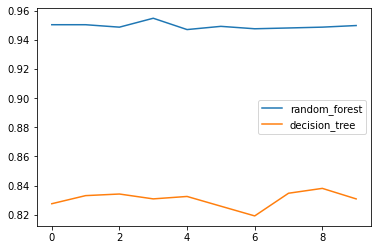

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

cv_list = {'random_forest': rf_cv_scores, 'decision_tree':dt_cv_scores}
df = pd.DataFrame(cv_list)
df.plot()
plt.show()

---
# 보팅(voting) 앙상블
: 단일 모델을 앙상블하여 더나은 예측을 하는 모델 생성


### 단일 모델 정확도 측정


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2
)

In [30]:
# 의사결정 나무
dtree = tree.DecisionTreeClassifier()
dree = dtree.fit(X_train, y_train)
dtree_score = dtree.score(X_test, y_test)
print("d-tree :", dtree_score)

d-tree : 0.8583333333333333


In [32]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier().fit(X_train, y_train)
knn_score = knn.score(X_test, y_test)
print("Knn :", knn_score)

Knn : 0.9777777777777777


In [42]:
# SVM
from sklearn.svm import SVC

svm = SVC(probability=True).fit(X_train, y_train)
svm_score = svm.score(X_test, y_test)
print("SVM :", svm_score)

SVM : 0.9833333333333333


### 하드 보팅
: 각각의 분류기의 예측값들을 모아, 가장 많은 득표를 받은 예측값으로 최종 결론을 내는 방식


In [43]:
from sklearn.ensemble import VotingClassifier

# 보통 확률이 더 높은 데이터에 weights 를 더 높게 줘야함

voting_clf = VotingClassifier(
    estimators=[('decision_tree', dtree), ('knn', knn), ('svm', svm)],
    weights=[1,1,1],
    voting='hard'
).fit(X_train, y_train)

voting_clf.score(X_test, y_test)

0.9777777777777777

### 소프트보팅
: 각각의 분류모델을 활용하여 모든 분류값들의 확률들을 더해서 가장 높은 점수를 획득한 분류값으로 최종결론을 내는 방식 입니다.


In [44]:
from sklearn.ensemble import VotingClassifier

# 보통 확률이 더 높은 데이터에 weights 를 더 높게 줘야함

voting_clf = VotingClassifier(
    estimators=[('decision_tree', dtree), ('knn', knn), ('svm', svm)],
    weights=[1,1,1],
    voting='soft',
).fit(X_train, y_train)

voting_clf.score(X_test, y_test)

0.9805555555555555

# 군집화(Clustering)
- 비지도학습으로 정답없이 특징만 가지고, 있는 데이터로 모델을 구현


In [45]:
import pandas as pd
df = pd.read_csv("../Data/student_kmeans.csv")
df.head()

,height,weight
0,185,60
1,180,60
2,185,70
3,165,63
4,155,68


In [49]:
import warnings
warnings.filterwarnings('ignore')

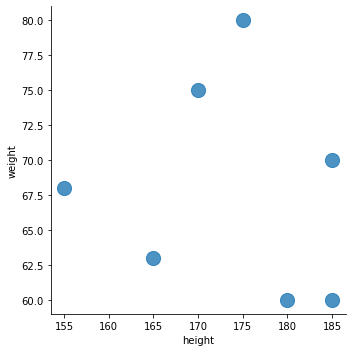

In [50]:
# 데이터 시각화
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(
    'height',
    'weight',
    data=df,
    fit_reg=False,
    scatter_kws={'s':200}
)

plt.show()

### K-Means 군집화

In [52]:
df.values

array([[185,  60],
       [180,  60],
       [185,  70],
       [165,  63],
       [155,  68],
       [170,  75],
       [175,  80]])

In [53]:
from sklearn.cluster import KMeans
data_points = df.values
kmeans = KMeans(
    n_clusters=3
).fit(data_points)

In [54]:
# 각 군집의 중심위치
kmeans.cluster_centers_

array([[183.33333333,  63.33333333],
       [172.5       ,  77.5       ],
       [160.        ,  65.5       ]])

In [56]:
df['cluster_id'] = kmeans.labels_
df

,height,weight,cluster_id
0,185,60,0
1,180,60,0
2,185,70,0
3,165,63,2
4,155,68,2
5,170,75,1
6,175,80,1


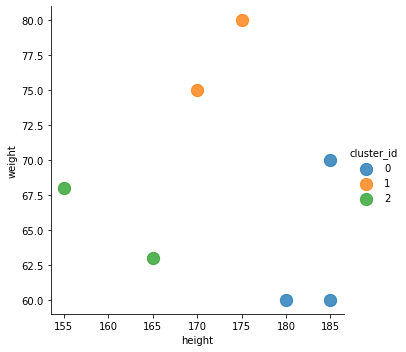

In [59]:
# 시각화
sns.lmplot(
    'height',
    'weight',
    data=df,
    fit_reg=False,
    scatter_kws={'s':150},
    hue='cluster_id'
)
plt.show()

---
### IRIS 군집화 비교

In [61]:
iris = pd.read_csv("../Data/iris.csv")

iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [70]:
# Name을 숫자로 변환
iris['label'] = iris["Name"].map({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2})
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,label,cluster_id
0,5.1,3.5,1.4,0.2,Iris-setosa,0,1
1,4.9,3.0,1.4,0.2,Iris-setosa,0,1
2,4.7,3.2,1.3,0.2,Iris-setosa,0,1
3,4.6,3.1,1.5,0.2,Iris-setosa,0,1
4,5.0,3.6,1.4,0.2,Iris-setosa,0,1


In [71]:
iris.tail()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,label,cluster_id
145,6.7,3.0,5.2,2.3,Iris-virginica,2,2
146,6.3,2.5,5.0,1.9,Iris-virginica,2,0
147,6.5,3.0,5.2,2.0,Iris-virginica,2,2
148,6.2,3.4,5.4,2.3,Iris-virginica,2,2
149,5.9,3.0,5.1,1.8,Iris-virginica,2,0


### k-Means 군집화

In [72]:
iris2 = iris[['SepalLength','SepalWidth','PetalLength','PetalWidth']]
iris2.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [73]:
data_points = iris2.values
kmeans = KMeans(n_clusters=3).fit(data_points)

In [74]:
# 중심점 확인
kmeans.cluster_centers_

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.418     , 1.464     , 0.244     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [75]:
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [76]:
iris['cluster_id'] = kmeans.labels_
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,label,cluster_id
0,5.1,3.5,1.4,0.2,Iris-setosa,0,1
1,4.9,3.0,1.4,0.2,Iris-setosa,0,1
2,4.7,3.2,1.3,0.2,Iris-setosa,0,1
3,4.6,3.1,1.5,0.2,Iris-setosa,0,1
4,5.0,3.6,1.4,0.2,Iris-setosa,0,1


# 시각화 해보기
cluster id의 일련번호가 틀리게 나올 수 있으므로 시각화를 통한 확인이 필요

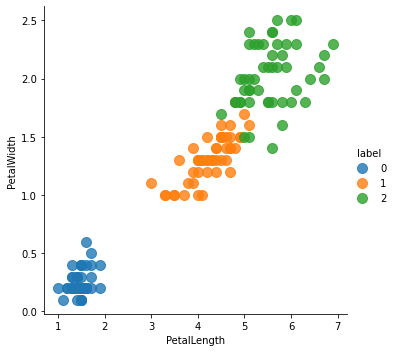

In [77]:
# 시각화
sns.lmplot(
    'PetalLength',
    'PetalWidth',
    data=iris,
    fit_reg=False,
    scatter_kws={'s':100},
    hue='label'
)
plt.show()

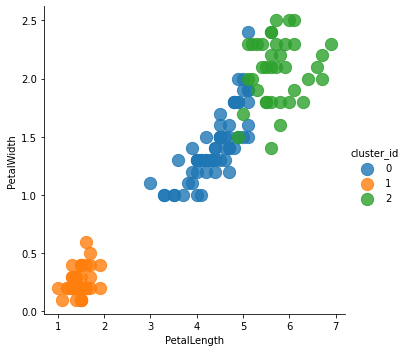

In [80]:
# 시각화
sns.lmplot(
    'PetalLength',
    'PetalWidth',
    data=iris,
    fit_reg=False,
    scatter_kws={'s':150},
    hue='cluster_id'
)
plt.show()

In [90]:
# cluster_id : 0 -> 2, 1 -> 0, 2 -> 1
iris['cluster_id2'] = iris["cluster_id"].map({0:1, 1:0, 2:2})
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,label,cluster_id,cluster_id2
0,5.1,3.5,1.4,0.2,Iris-setosa,0,1,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0,1,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0,1,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0,1,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0,1,0


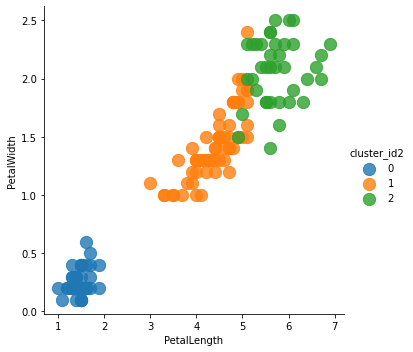

In [91]:
# 시각화
sns.lmplot(
    'PetalLength',
    'PetalWidth',
    data=iris,
    fit_reg=False,
    scatter_kws={'s':150},
    hue='cluster_id2'
)
plt.show()

In [92]:
from sklearn.metrics import accuracy_score
accuracy_score(iris.label, iris.cluster_id2)

0.8933333333333333